In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
import os
import glob
import calendar

In [3]:
def find_missing_date_ranges(directory):
    results = []

    # Loop over files in the directory
    for file in os.listdir(directory):
        if file.endswith("_merged.nc"):  # Ensure only relevant files are processed
            file_path = os.path.join(directory, file)

            try:
                # Open the netCDF file
                ds = xr.open_dataset(file_path)

                # Extract time variable and convert to pandas datetime
                if 'time' in ds.variables:
                    time_data = pd.to_datetime(ds['time'].values)

                    # Identify gaps in the time series
                    full_range = pd.date_range(start=time_data.min(), end=time_data.max(), freq='ME')
                    missing_dates = full_range.difference(time_data)

                    if not missing_dates.empty:
                        # Identify missing data ranges
                        missing_periods = []
                        start_date = missing_dates[0]

                        for i in range(1, len(missing_dates)):
                            if (missing_dates[i] - missing_dates[i-1]).days > 31:  # Check for break in sequence
                                end_date = missing_dates[i-1]
                                missing_periods.append(f"{start_date.strftime('%B %Y')} to {end_date.strftime('%B %Y')}")
                                start_date = missing_dates[i]

                        # Append last missing range
                        missing_periods.append(f"{start_date.strftime('%B %Y')} to {missing_dates[-1].strftime('%B %Y')}")

                        # Format file name
                        file_name = file.replace("_merged.nc", "")
                        results.append((file_name, ", ".join(missing_periods)))

                ds.close()
            except Exception as e:
                print(f"Error processing {file}: {e}")

    # Sort results by model name (last part of the file name)
    results.sort(key=lambda x: x[0].split("_")[-1])

    return results

# Example usage
directory = "/content/drive/MyDrive/capstone_data/netCDF/"
missing_data_info = find_missing_date_ranges(directory)

# Print the results
for file_name, missing_range in missing_data_info:
    print(f"{file_name}: {missing_range}")


KeyboardInterrupt: 

HAHAHAH

In [4]:
eea_ncep_path = '/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NCEP_merged.nc'
eea_ncep = xr.open_dataset(eea_ncep_path)

eea_ncep_slice = eea_ncep["precip"]
eea_ncep = eea_ncep.to_dataframe().reset_index()

eea_ncep

,lead_time,time,M,latitude,longitude,predicted_precip,precip
0,0.5,1982-01-01,1.0,-3.5,38.0,3.40875,11.374672
1,0.5,1982-01-01,1.0,-3.5,38.5,3.40875,12.559185
2,0.5,1982-01-01,1.0,-3.5,39.0,2.29554,12.911411
3,0.5,1982-01-01,1.0,-3.5,39.5,2.29554,11.975130
4,0.5,1982-01-01,1.0,-3.5,40.0,0.76518,NaN
...,...,...,...,...,...,...,...
54431995,9.5,2024-12-01,24.0,8.0,48.0,NaN,0.612805
54431996,9.5,2024-12-01,24.0,8.0,48.5,NaN,0.271429
54431997,9.5,2024-12-01,24.0,8.0,49.0,NaN,0.280411
54431998,9.5,2024-12-01,24.0,8.0,49.5,NaN,2.345316


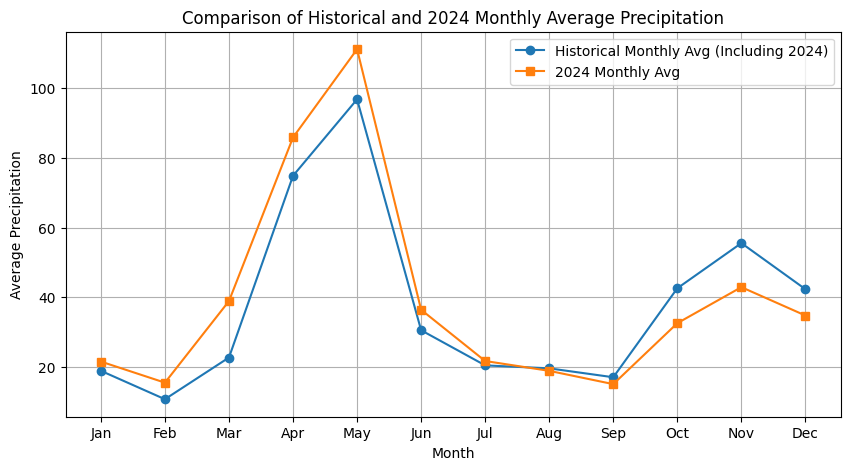

In [5]:
# Ensure the 'time' column is in datetime format
eea_ncep['time'] = pd.to_datetime(eea_ncep['time'])
eea_ncep['predicted_precip'] = eea_ncep['predicted_precip'] * 30

# Extract year and month
eea_ncep['year'] = eea_ncep['time'].dt.year
eea_ncep['month'] = eea_ncep['time'].dt.month

# Compute historical monthly averages (including 2024)
historical_avg = eea_ncep.groupby('month')['predicted_precip'].mean()

# Compute 2024 monthly averages
avg_2024 = eea_ncep[eea_ncep['year'] == 2024].groupby('month')['predicted_precip'].mean()

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(historical_avg.index, historical_avg.values, marker='o', linestyle='-', label="Historical Monthly Avg (Including 2024)")
plt.plot(avg_2024.index, avg_2024.values, marker='s', linestyle='-', label="2024 Monthly Avg")

plt.xlabel("Month")
plt.ylabel("Average Precipitation")
plt.title("Comparison of Historical and 2024 Monthly Average Precipitation")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


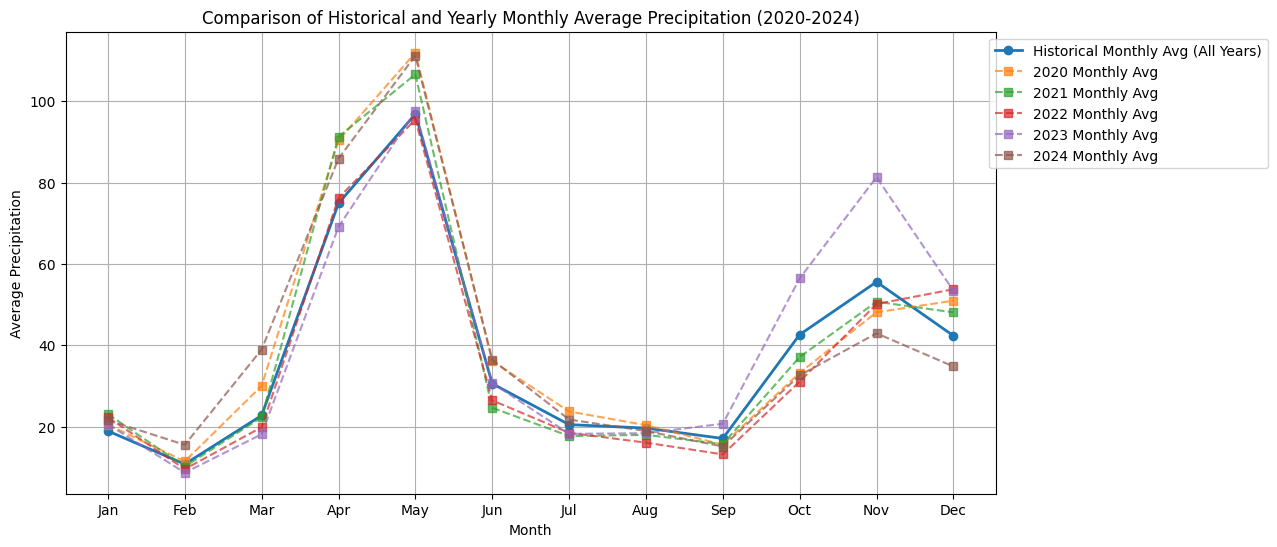

In [6]:
# Compute yearly monthly averages for 2020-2024
yearly_avg = eea_ncep[(eea_ncep['year'] >= 2020) & (eea_ncep['year'] <= 2024)].groupby(['year', 'month'])['predicted_precip'].mean().unstack(level=0)

# Plotting
plt.figure(figsize=(12, 6))

# Plot historical average
plt.plot(historical_avg.index, historical_avg.values, marker='o', linestyle='-', linewidth=2, label="Historical Monthly Avg (All Years)")

# Plot yearly averages from 2020 to 2024
for year in yearly_avg.columns:
    plt.plot(yearly_avg.index, yearly_avg[year], marker='s', linestyle='--', alpha=0.7, label=f"{year} Monthly Avg")

plt.xlabel("Month")
plt.ylabel("Average Precipitation")
plt.title("Comparison of Historical and Yearly Monthly Average Precipitation (2020-2024)")
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
plt.grid(True)

# Show the plot
plt.show()


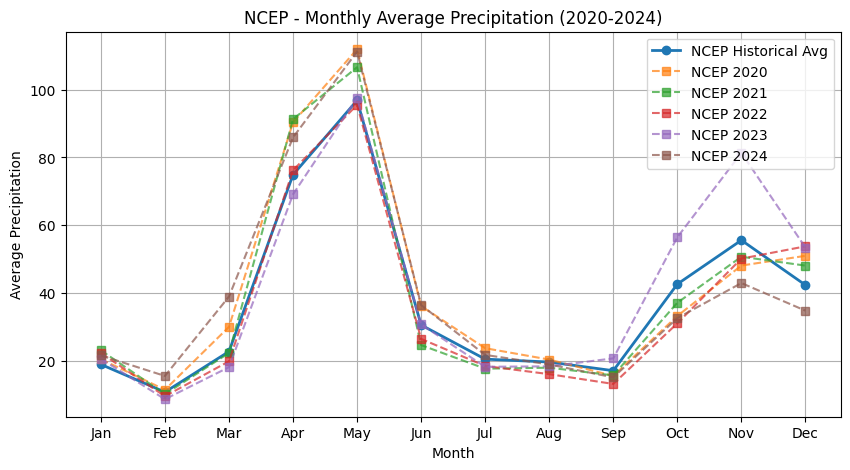

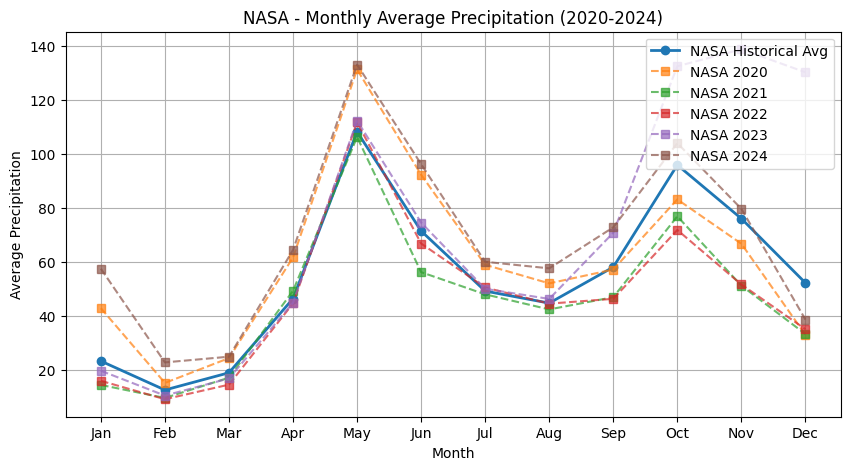

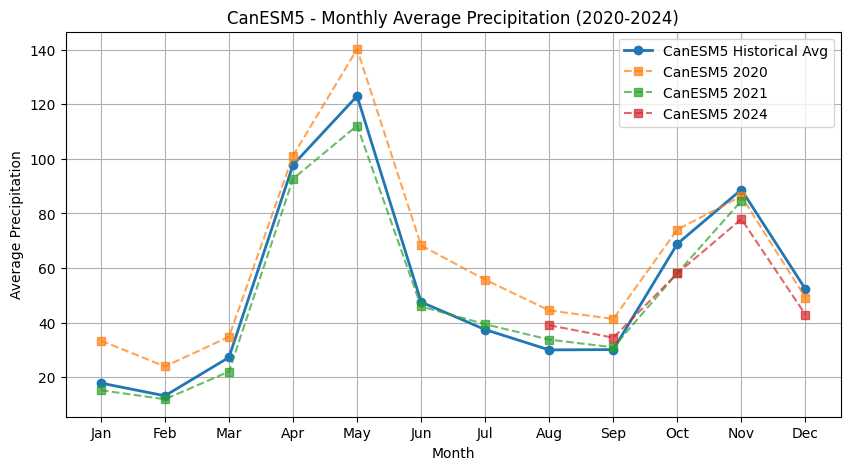

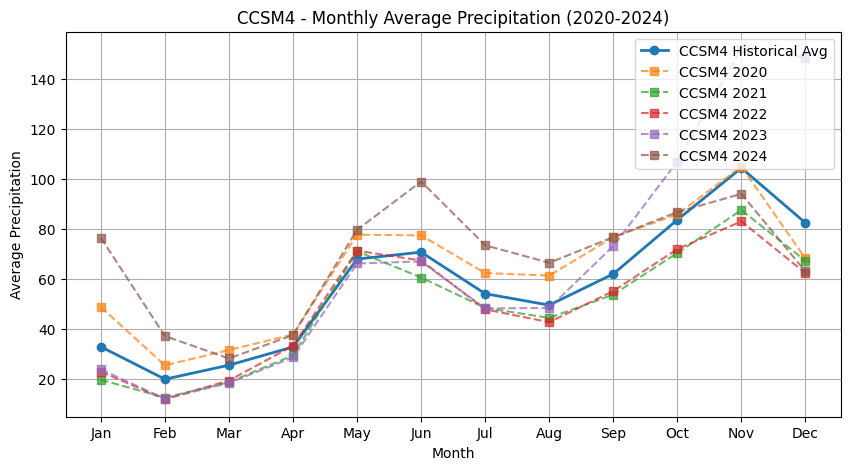

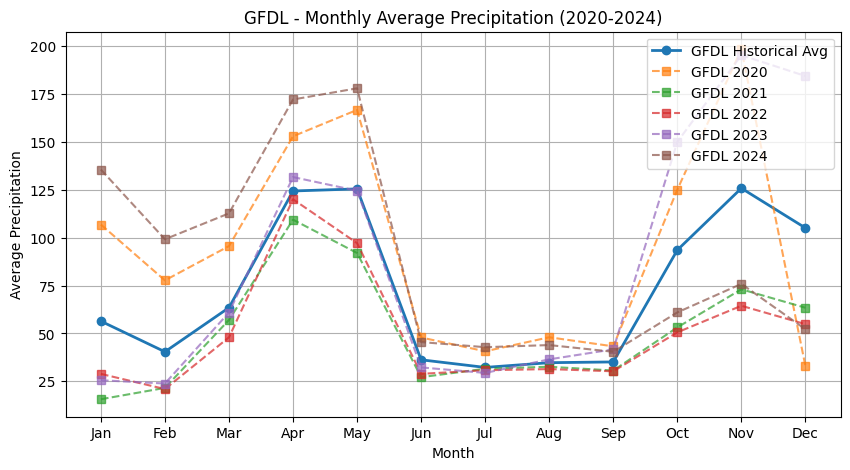

In [7]:
# Define file paths for all models
model_paths = {
    "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NCEP_merged.nc",
    "NASA": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NASA_merged.nc",
    "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_CanESM5_merged.nc",
    "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_CCSM4_merged.nc",
    "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_GFDL_merged.nc"
}


# Dictionary to store results for each model
model_results = {}

for model, path in model_paths.items():
    try:
        # Load dataset
        dataset = xr.open_dataset(path)

        ##### when slicing to the precip or predicted_precip, then one of the columns is gone, that clears out the whole column leading to missing data. How do I make it possible to slice the data into dataframe and not miss out on any of the columns?
        # Convert to DataFrame
        df = dataset.to_dataframe().reset_index()
        df["predicted_precip"] = df["predicted_precip"] * 30

        # Ensure the 'time' column is in datetime format
        df['time'] = pd.to_datetime(df['time'])

        # Extract year and month
        df['year'] = df['time'].dt.year
        df['month'] = df['time'].dt.month

        # Compute historical monthly averages (all years)
        historical_avg = df.groupby('month')['predicted_precip'].mean()

        # Compute yearly monthly averages for 2020-2024
        yearly_avg = df[(df['year'] >= 2020) & (df['year'] <= 2024)].groupby(['year', 'month'])['predicted_precip'].mean().unstack(level=0)

        # Store results
        model_results[model] = {"historical_avg": historical_avg, "yearly_avg": yearly_avg}

    except FileNotFoundError:
        print(f"File not found: {path}, skipping {model}.")
    except Exception as e:
        print(f"Error processing {model}: {e}")

# Plot separate figures for each model
for model, results in model_results.items():
    plt.figure(figsize=(10, 5))

    historical_avg = results["historical_avg"]
    yearly_avg = results["yearly_avg"]

    # Plot historical average
    plt.plot(historical_avg.index, historical_avg.values, marker='o', linestyle='-', linewidth=2, label=f"{model} Historical Avg")

    # Plot yearly averages from 2020 to 2024
    for year in yearly_avg.columns:
        plt.plot(yearly_avg.index, yearly_avg[year], marker='s', linestyle='--', alpha=0.7, label=f"{model} {year}")

    plt.xlabel("Month")
    plt.ylabel("Average Precipitation")
    plt.title(f"{model} - Monthly Average Precipitation (2020-2024)")
    plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
    plt.legend(loc='upper right')
    plt.grid(True)

    # Show the plot
    plt.show()


Overall Seasonal Pattern

Notice the peaks and valleys in the historical average line (green). For many parts of Eastern Africa, there is a primary rainy season around March–May and often a secondary rainy season around October–December.
Compare the individual years (2020–2024) to see how they follow or deviate from this typical seasonal pattern.
Comparison With the Historical Average

Identify months where a particular year’s precipitation is above or below the historical average. For instance:
If the orange line (2020) is above the green line in April, it suggests April 2020 was wetter than usual.
If the red line (2022) is below the green line in November, it suggests November 2022 was drier than the long-term norm.
This helps you see how unusual or typical each year’s precipitation was in any given month.
Interannual Variability

Look for differences among the years themselves. Do certain years consistently trend higher or lower than others?
For instance, if 2021 consistently sits above the historical average across multiple months, it might indicate a wetter-than-normal year overall, whereas 2023 might be close to or below average in most months, indicating drier conditions.


=== Processing region: eastern_east_africa ===


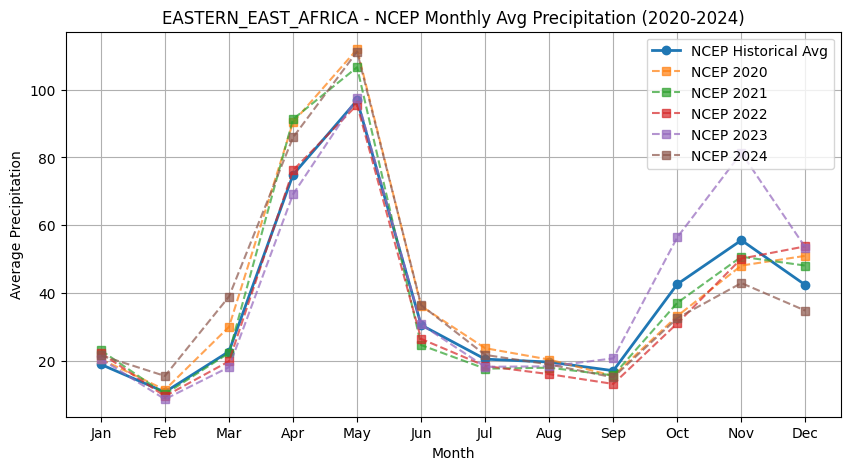

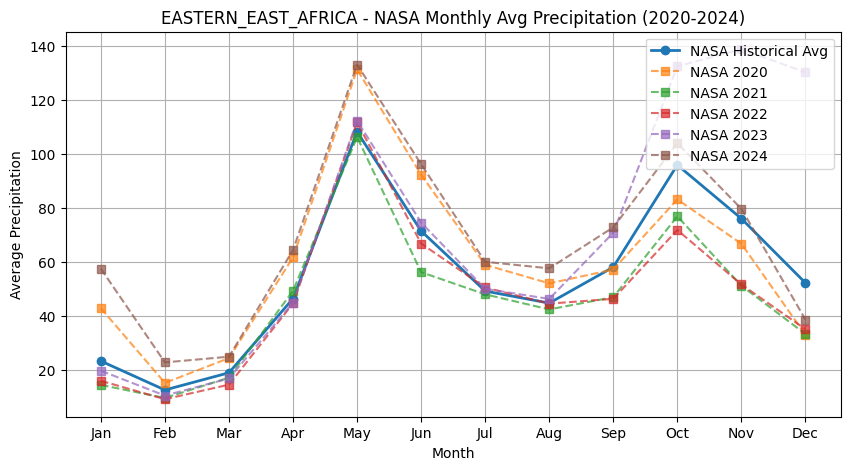

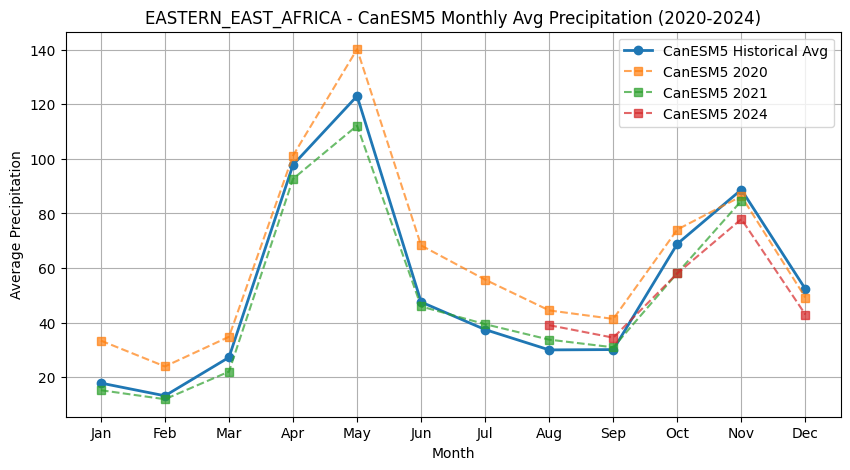

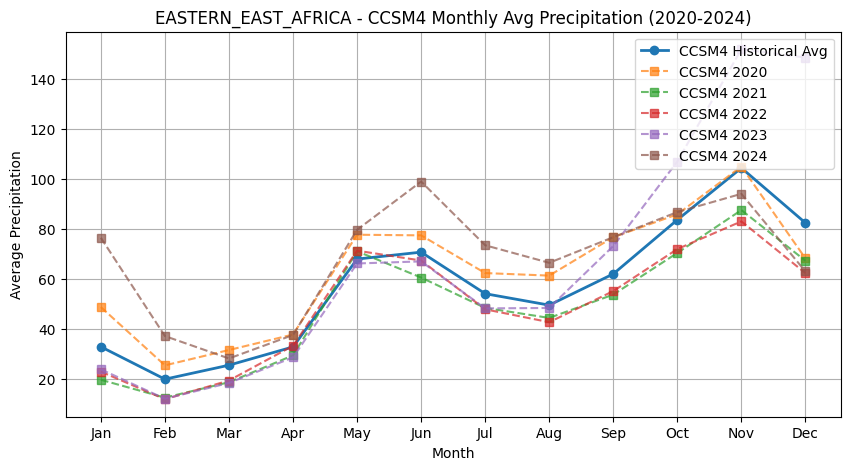

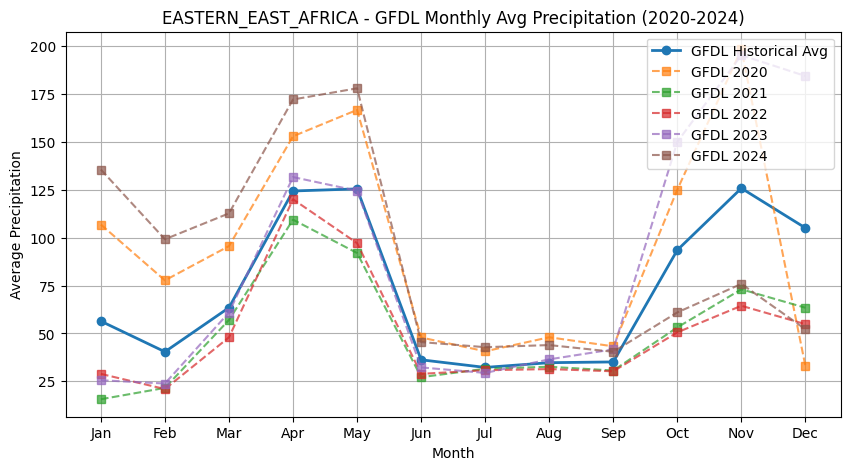

=== Processing region: south_sudan ===


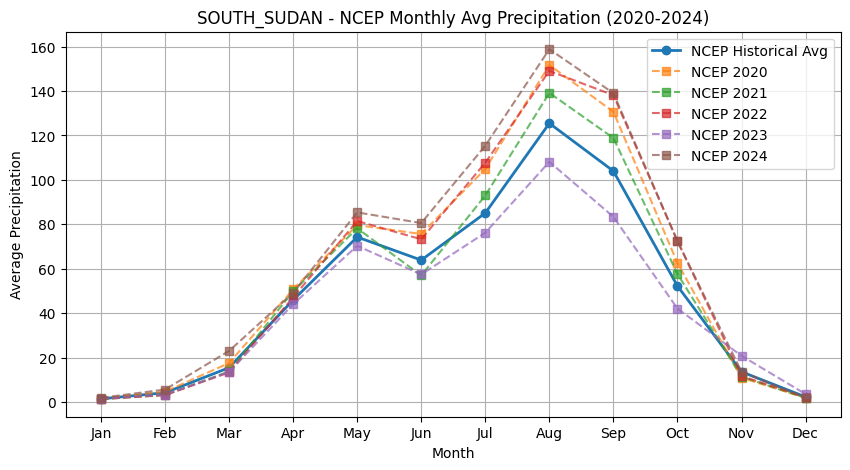

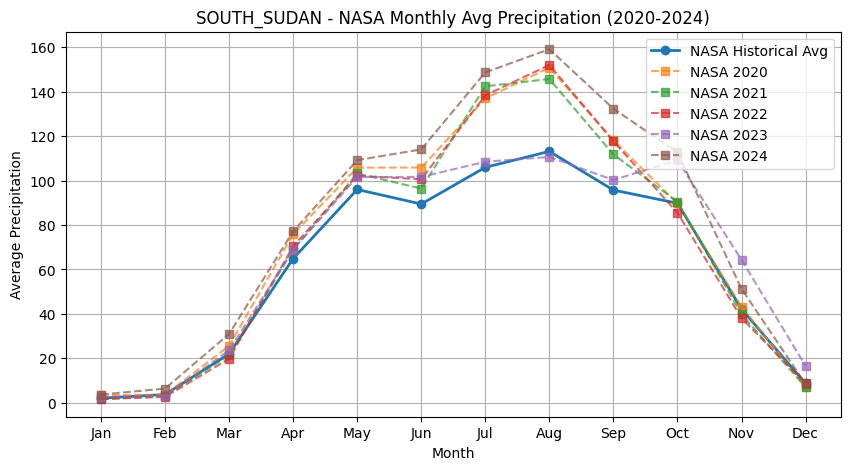

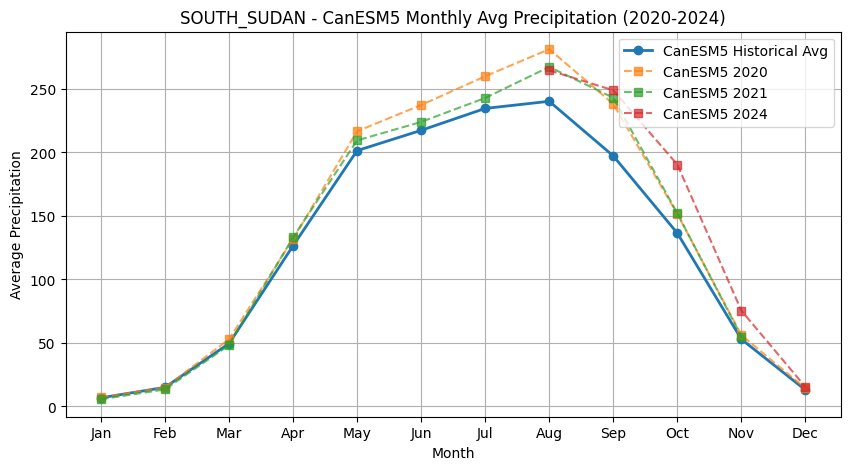

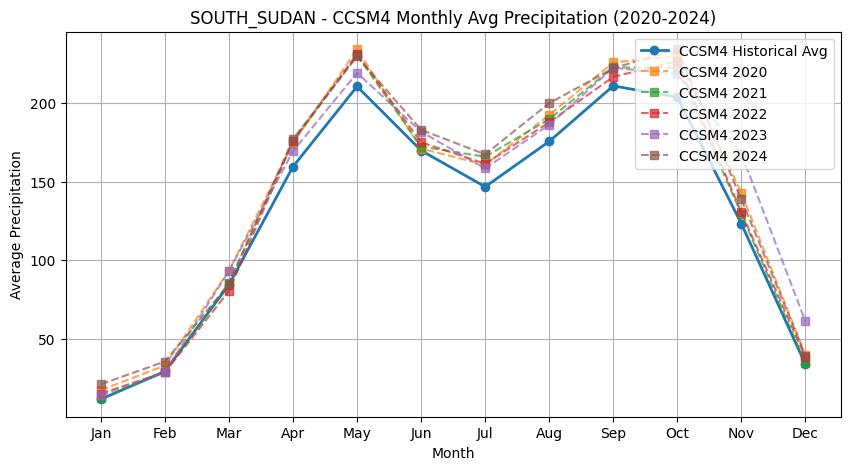

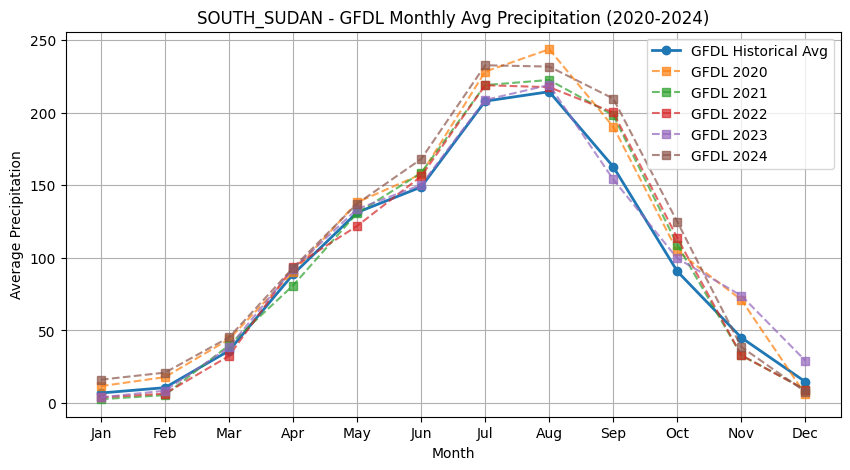

=== Processing region: eastern_ukraine ===


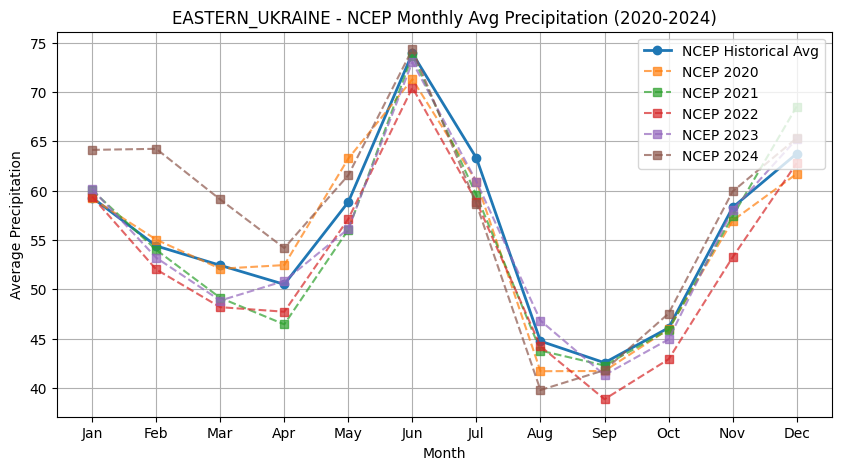

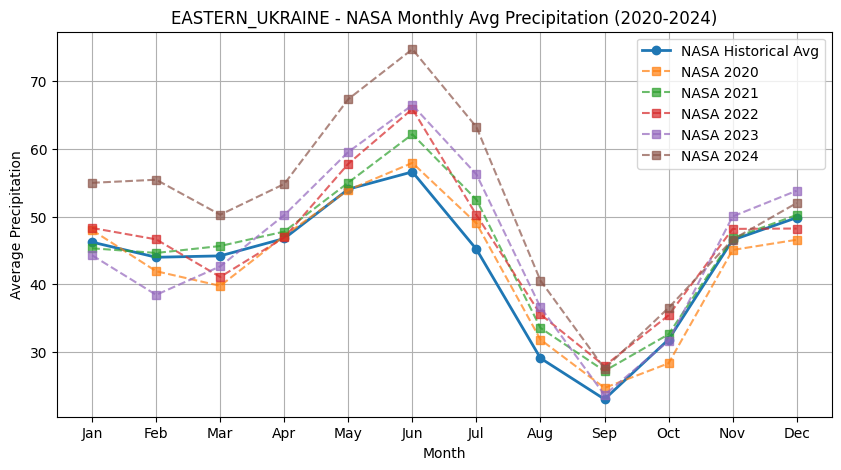

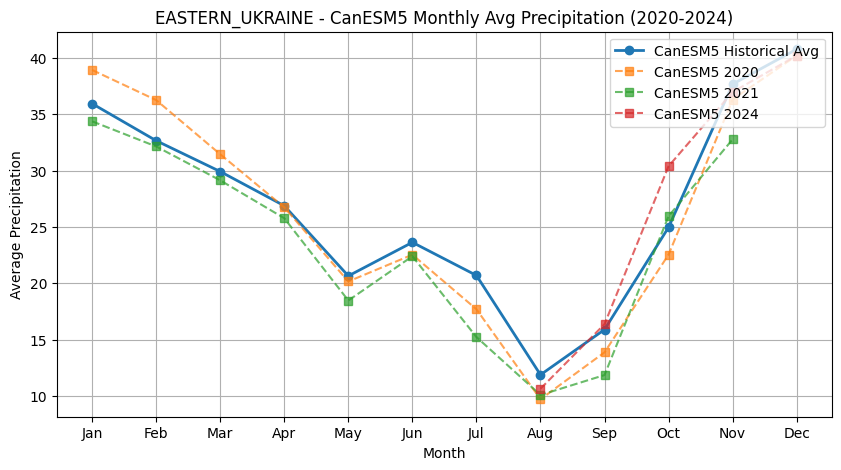

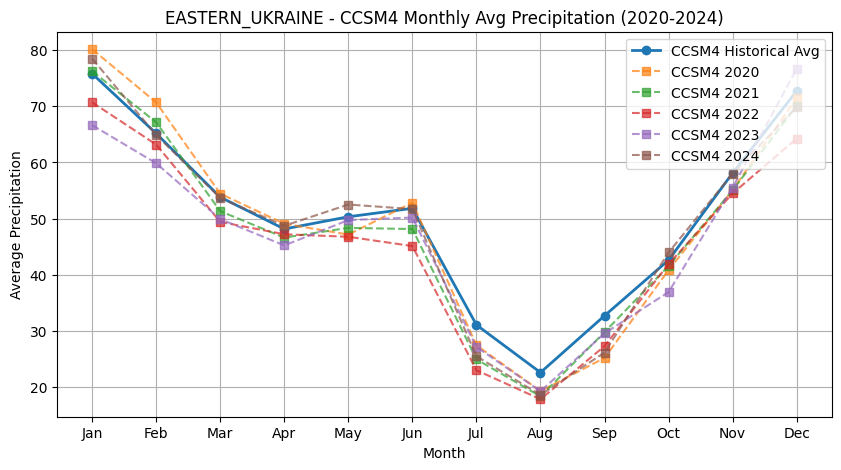

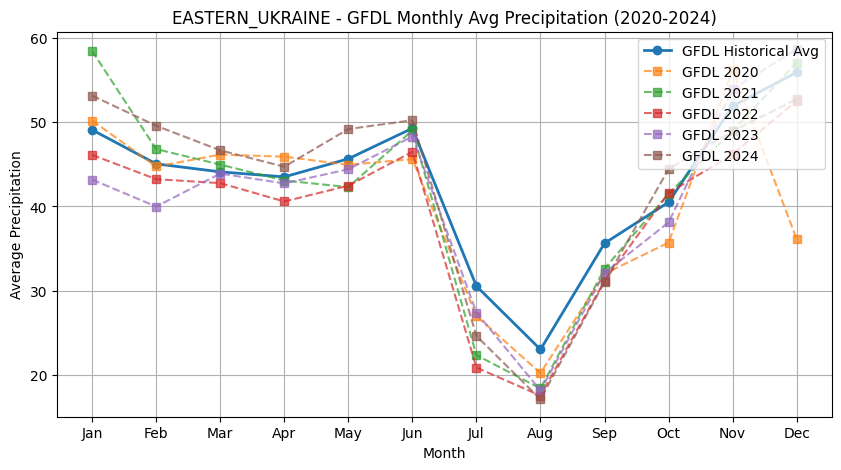

=== Processing region: lake_victoria_basin ===


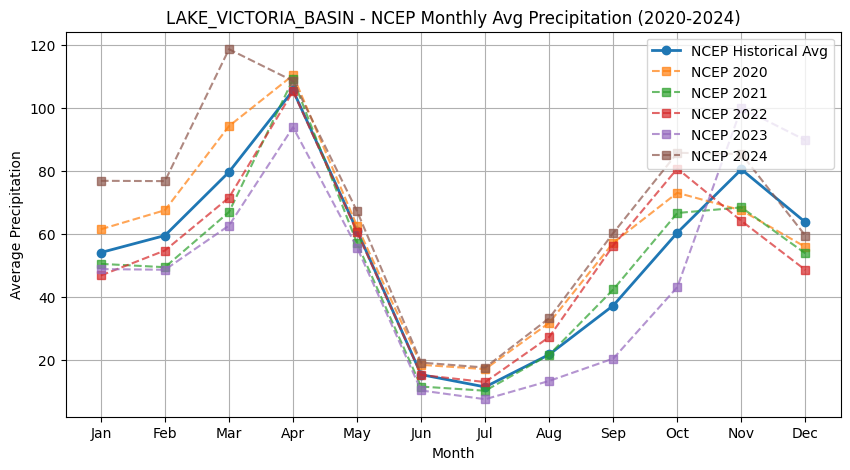

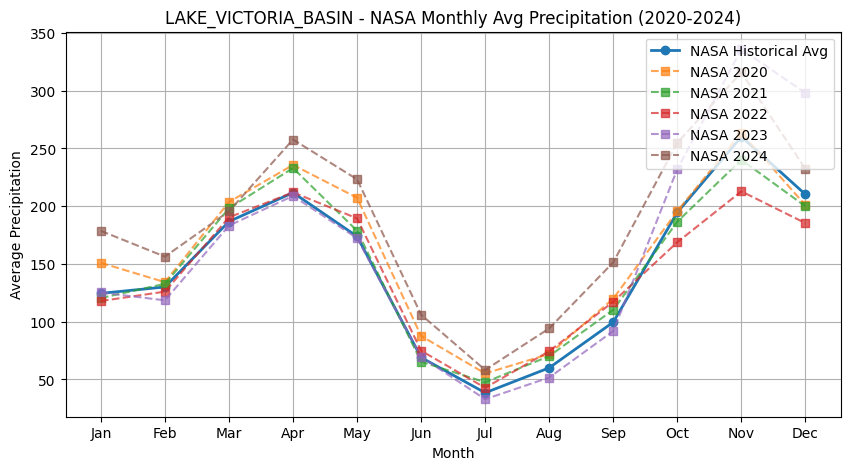

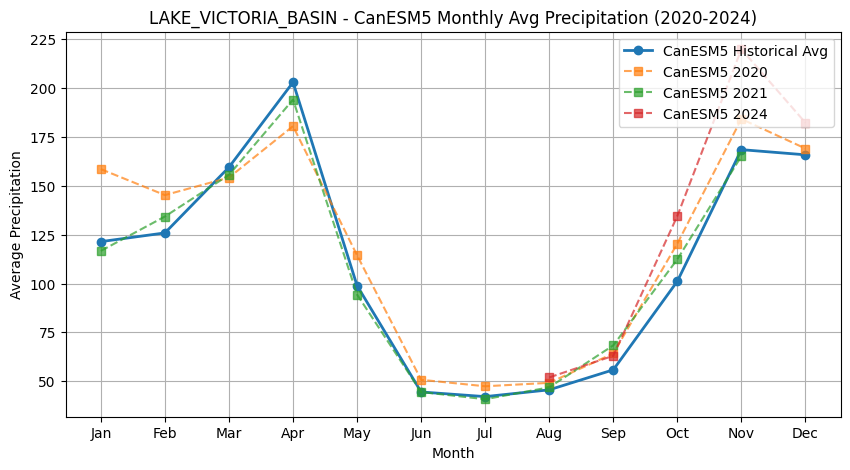

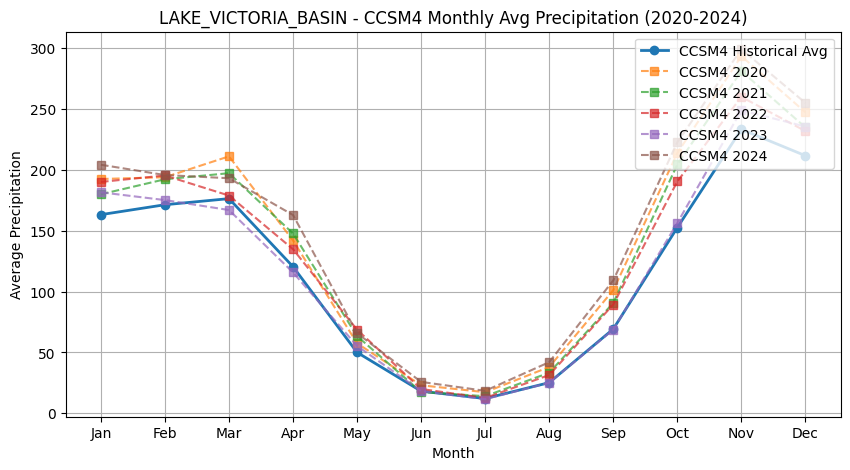

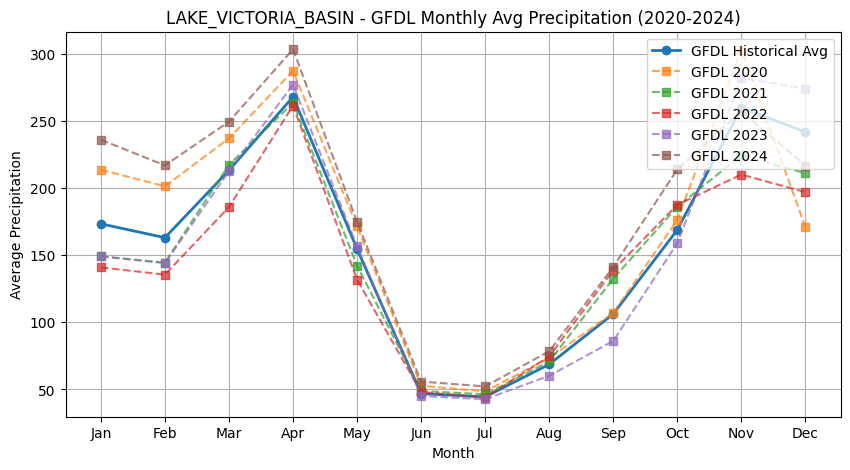

In [6]:
# Dictionary of dictionaries:
# Outer keys = region names
# Inner keys = model names
# Values = file paths to the corresponding NetCDF files

region_model_paths = {
    "eastern_east_africa": {
    "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NCEP_merged.nc",
    "NASA": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NASA_merged.nc",
    "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_CanESM5_merged.nc",
    "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_CCSM4_merged.nc",
    "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_GFDL_merged.nc"
    },
    "south_sudan": {
        "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_NCEP_merged.nc",
        "NASA": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_NASA_merged.nc",
        "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_CanESM5_merged.nc",
        "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_CCSM4_merged.nc",
        "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_GFDL_merged.nc"
    },
    "eastern_ukraine": {
        "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_NCEP_merged.nc",
        "NASA": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_NASA_merged.nc",
        "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_CanESM5_merged.nc",
        "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_CCSM4_merged.nc",
        "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_GFDL_merged.nc"
    },
    "lake_victoria_basin": {
        "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_NCEP_merged.nc",
        "NASA": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_NASA_merged.nc",
        "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_CanESM5_merged.nc",
        "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_CCSM4_merged.nc",
        "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_GFDL_merged.nc"
    }
}

# Loop through each region
for region, model_paths in region_model_paths.items():
    print(f"=== Processing region: {region} ===")

    # Dictionary to store results for each model within this region
    model_results = {}

    # Loop through each model for the current region
    for model, path in model_paths.items():
        try:
            # Load dataset
            dataset = xr.open_dataset(path)

            # Convert to DataFrame
            df = dataset.to_dataframe().reset_index()
            df["predicted_precip"] = df["predicted_precip"] * 30

            # Ensure the 'time' column is in datetime format
            df['time'] = pd.to_datetime(df['time'])

            # Extract year and month
            df['year'] = df['time'].dt.year
            df['month'] = df['time'].dt.month

            # Compute historical monthly averages (all years in the dataset)
            historical_avg = df.groupby('month')['predicted_precip'].mean()

            # Compute yearly monthly averages for 2020-2024
            yearly_avg = (
                df[(df['year'] >= 2020) & (df['year'] <= 2024)]
                .groupby(['year', 'month'])['predicted_precip']
                .mean()
                .unstack(level=0)
            )

            # Store results
            model_results[model] = {"historical_avg": historical_avg, "yearly_avg": yearly_avg}

        except FileNotFoundError:
            print(f"File not found: {path}, skipping {model}.")
        except Exception as e:
            print(f"Error processing {model}: {e}")

    # Now plot separate figures for each model within this region
    for model, results in model_results.items():
        plt.figure(figsize=(10, 5))

        historical_avg = results["historical_avg"]
        yearly_avg = results["yearly_avg"]

        # Plot historical average
        plt.plot(
            historical_avg.index,
            historical_avg.values,
            marker='o',
            linestyle='-',
            linewidth=2,
            label=f"{model} Historical Avg"
        )

        # Plot yearly averages from 2020 to 2024
        if yearly_avg is not None:
            for year in yearly_avg.columns:
                plt.plot(
                    yearly_avg.index,
                    yearly_avg[year],
                    marker='s',
                    linestyle='--',
                    alpha=0.7,
                    label=f"{model} {year}"
                )

        plt.xlabel("Month")
        plt.ylabel("Average Precipitation")
        plt.title(f"{region.upper()} - {model} Monthly Avg Precipitation (2020-2024)")
        plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()


In [ ]:


# Define file paths for all regions and models
region_model_paths = {
    "eastern_east_africa": {
        "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NCEP_merged.nc",
        "NASA": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_NASA_merged.nc",
        "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_CanESM5_merged.nc",
        "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_CCSM4_merged.nc",
        "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/eastern_east_africa_GFDL_merged.nc"
    },
    "south_sudan": {
        "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_NCEP_merged.nc",
        "NASA": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_NASA_merged.nc",
        "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_CanESM5_merged.nc",
        "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_CCSM4_merged.nc",
        "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/south_sudan_GFDL_merged.nc"
    },
    #"eastern_ukraine": {
     #   "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_NCEP_merged.nc",
    #  "NASA": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_NASA_merged.nc",
    #    "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_CanESM5_merged.nc",
    #    "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_CCSM4_merged.nc",
     #   "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/eastern_ukraine_GFDL_merged.nc"
   # },
    #"lake_victoria_basin": {
     #   "NCEP": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_NCEP_merged.nc",
      #  "NASA": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_NASA_merged.nc",
      #  "CanESM5": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_CanESM5_merged.nc",
      #  "CCSM4": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_CCSM4_merged.nc",
      #  "GFDL": "/content/drive/MyDrive/capstone_data/netCDF/lake_victoria_basin_GFDL_merged.nc"
    #}
}

# Dictionary to hold aggregated data for each region
region_data = {}

# Loop over each region, load and combine data from all models
for region, models in region_model_paths.items():
    df_list = []
    for model, path in models.items():
        try:
            # Load dataset
            ds = xr.open_dataset(path)
            # Convert entire dataset to DataFrame (to keep all variables)
            df = ds.to_dataframe().reset_index()
            df["predicted_precip"] = df["predicted_precip"] * 30
            # Convert time to datetime and extract year/month
            df['time'] = pd.to_datetime(df['time'])
            df['year'] = df['time'].dt.year
            df['month'] = df['time'].dt.month
            df_list.append(df)
        except Exception as e:
            print(f"Error processing {region} {model}: {e}")
    if df_list:
        # Combine data from all models for the region
        region_data[region] = pd.concat(df_list, axis=0)

# Define years to plot (rows)
years_to_plot = [2020, 2021, 2022, 2023, 2024]
# Define regions (columns) in a specific order
regions = list(region_model_paths.keys())

# Create grid: 5 rows (years) x 4 columns (regions)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(20, 20), sharex=True, sharey=True)

# Loop over each region (column) and year (row)
for col_idx, region in enumerate(regions):
    # Get the combined dataframe for this region
    df_region = region_data.get(region)
    if df_region is None:
        continue
    # Compute the historical monthly average for predicted_precip across all years
    historical_avg = df_region.groupby('month')["predicted_precip"].mean()

    for row_idx, year in enumerate(years_to_plot):
        ax = axes[row_idx, col_idx]
        # Filter data for the current year
        df_year = df_region[df_region['year'] == year]
        # Compute monthly average for this year
        year_avg = df_year.groupby('month')["predicted_precip"].mean()

        # Plot historical average (common for region)
        ax.plot(historical_avg.index, historical_avg.values,
                marker='o', linestyle='-', linewidth=2, color='gray', label="Hist. Avg")
        # Plot the current year's monthly averages
        ax.plot(year_avg.index, year_avg.values,
                marker='s', linestyle='--', alpha=0.8, label=str(year))

        ax.set_xticks(range(1, 13))
        ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
        ax.grid(True)
        if row_idx == 0:
            ax.set_title(region.replace("_", " ").title())
        if col_idx == 0:
            ax.set_ylabel(str(year))
        else:
            ax.set_ylabel("")
        # Optionally, add a legend to the top row
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8)

# Set common x and y labels for the entire grid
fig.text(0.5, 0.04, 'Month', ha='center', fontsize=14)
fig.text(0.04, 0.5, 'Predicted Precipitation', va='center', rotation='vertical', fontsize=14)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.suptitle("Historical vs. Yearly Monthly Average Predicted Precipitation\n(Columns: Regions, Rows: Years 2020-2024)", fontsize=16)
plt.show()
